#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

#### Load Preprocessed Data

In [ ]:
import joblib as jl

X_train, X_val, X_test, y_train, y_val, y_test = jl.load('/home/kali/Documents/IDS-Project/dataset/CICIDS2017_FeatureSelected.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/nimma/Downloads/IDS-PROJECT/models/preprocessed_data.pkl'

#### Create Evaluation Function

In [ ]:
def evaluate_model(model,X,y):
    pred = model.predict(X)

    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(
            y, pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y, pred,
            average="weighted",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y, pred,
            average="weighted",
            zero_division=0
        )
    }

#### Train Logistic Regression

In [9]:
scaler = jl.load('C:/Users/nimma/Downloads/IDS-PROJECT/models/scaler.pkl')

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_results = evaluate_model(lr, X_val_scaled, y_val)

#### Train Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

rf_result = evaluate_model(
    rf,
    X_val,
    y_val
)

#### Train Decision Tree

In [11]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_result = evaluate_model(
    dt,
    X_val,
    y_val
)

#### Train XGBoost

In [12]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.5 MB/s eta 0:00:28
   ---------------------------------------- 0.5/69.5 MB 2.5 MB/s eta 0:00:28
   ---------------------------------------- 0.8/69.5 MB 966.3 kB/s eta 0:01:12
   ---------------------------------------- 0.8/69.5 MB 966.3 kB/s eta 0:01:12
    --------------------------------------- 1.0/69.5 MB 834.2 kB/s eta 0:01:23
    --------------------------------------- 1.3/69.5 MB 910.9 kB/s eta 0:01:15
    --------------------------------------- 1.6/69.5 MB 930.5 kB/s eta 0:01:14
   - -------------------------------------- 1.8/69.5 MB 947.8 kB/s eta 0:01:12
   - -------------------------------------- 1.8/69.5 MB 947.8 kB/s eta 0:01:12
   - -------------------------------------- 2.1/69.5 MB 973.0 kB/s eta 0:01:10
   - -------------------------------------- 2.6/69.5 MB 1.0 MB/s eta 0:01:

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    tree_method="hist",
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

xgb_result = evaluate_model(
    xgb,
    X_val,
    y_val
)

#### Train LightGBM

In [15]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 952.8 kB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 952.8 kB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 952.8 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 626.9 kB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 683.0 kB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 683.0 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 721.8 kB/s  0:00:02


In [17]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    random_state=42,
)

lgb.fit(X_train, y_train)

lgb_result = evaluate_model(
    lgb,
    X_val,
    y_val
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7439
[LightGBM] [Info] Number of data points in the train set: 1613310, number of used features: 39
[LightGBM] [Info] Start training from score -0.184995
[LightGBM] [Info] Start training from score -7.166105
[LightGBM] [Info] Start training from score -2.980190
[LightGBM] [Info] Start training from score -5.501553
[LightGBM] [Info] Start training from score -2.679933
[LightGBM] [Info] Start training from score -6.178278
[LightGBM] [Info] Start training from score -6.148829
[LightGBM] [Info] Start training from score -6.052095
[LightGBM] [Info] Start training from score -12.347888
[LightGBM] [Info] Start training from score -11.158304
[LightGBM] [Info] Start

#### Train CatBoost

In [18]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 743.7 kB/s eta 0:02:15
   ---------------------------------------- 0.8/100.2 MB 1.2 MB/s eta 0:01:27
   ---------------------------------------- 0.8/100.2 MB 1.2 MB/s eta 0:01:27
   ---------------------------------------- 1.0/100.2 MB 867.4 kB/s eta 0:01:55
   ---------------------------------------- 1.0/100.2 MB 867.4 kB/s eta 0:01:55
   ---------------------------------------- 1.0/100.2 MB 867.4 kB/s eta 0:01:55
    --------------------------------------- 1.3/100.2 MB 708.3 kB/s eta 0:02:20
    --------------

#### Train Isolation Forest

In [2]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

df = pd.read_csv('/home/kali/Documents/IDS-Project/dataset/CICIDS2017_FeatureSelected.csv')


# Create binary labels
# BENIGN = 1, Attack = -1
y_train_binary = np.where(df.loc[X_train.index, "Label"] == "BENIGN", 1, -1)
y_val_binary = np.where(df.loc[X_val.index, "Label"] == "BENIGN", 1, -1)

iso = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42
)

iso.fit(X_train)

pred = iso.predict(X_val)

print(classification_report(y_val_binary, pred))

NameError: name 'X_train' is not defined

### Compare Models

In [ ]:
results = pd.DataFrame([
    ["Logistic Regression", *lr_results.values()],
    ["Random Forest", *rf_result.values()],
    ["Decision Tree", *dt_result.values()],
    ["XGBoost", *xgb_result.values()],
    ["LightGBM", *lgb_result.values()]
], columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
])

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.973981   0.974658  0.973981  0.973370
1        Random Forest  0.998411   0.998364  0.998411  0.998372
2        Decision Tree  0.998031   0.998039  0.998031  0.998034
3              XGBoost  0.983520   0.983483  0.983520  0.983448
4             LightGBM  0.755950   0.892541  0.755950  0.808097


#### Visualize the results

<Figure size 1000x600 with 0 Axes>

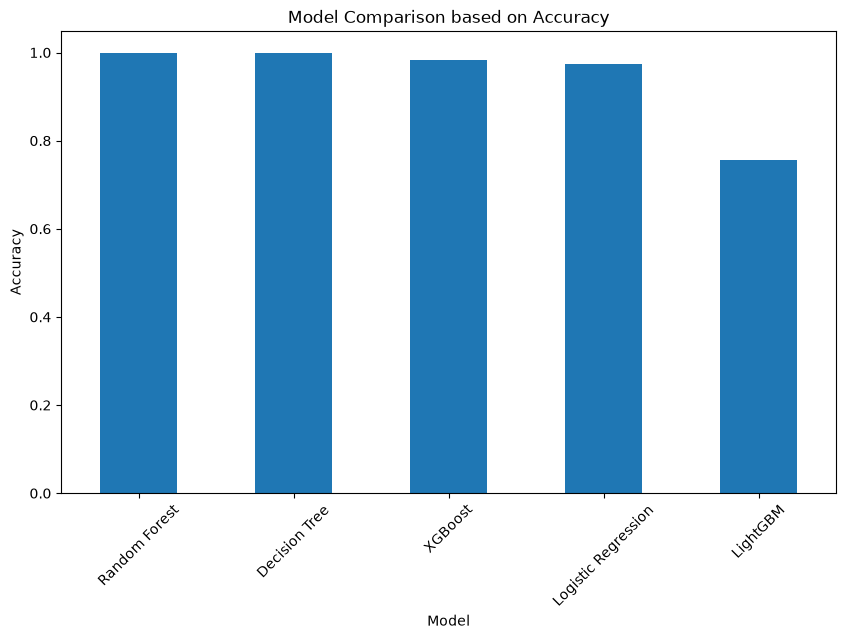

<Figure size 1000x600 with 0 Axes>

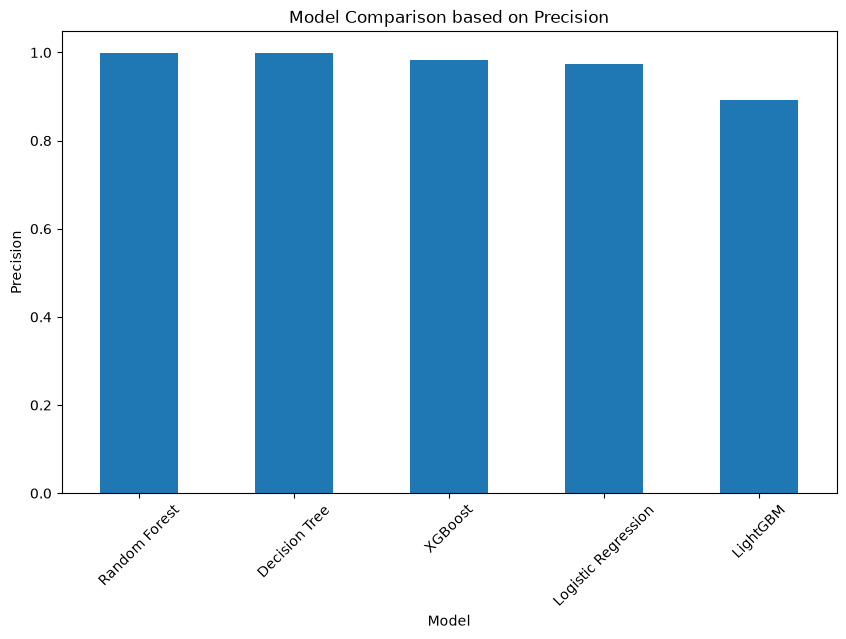

<Figure size 1000x600 with 0 Axes>

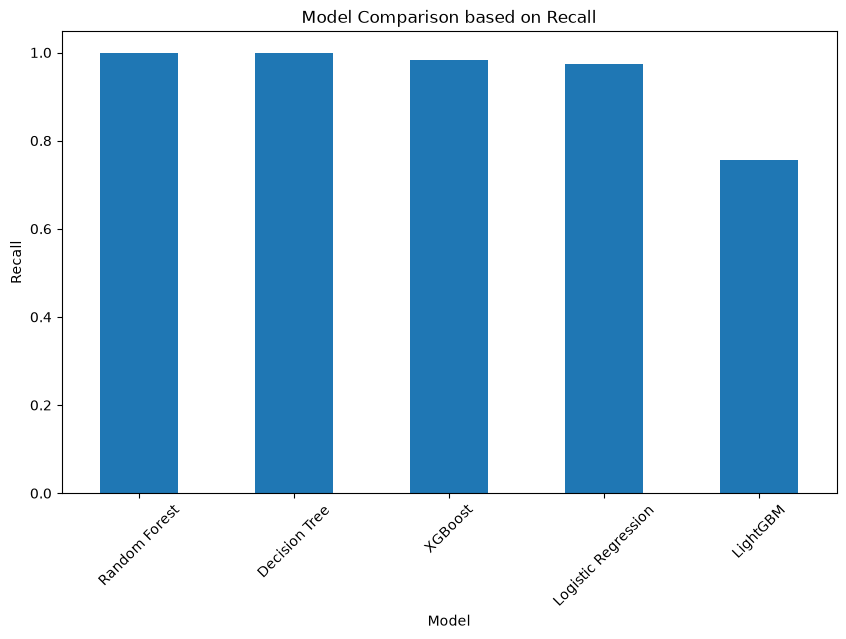

<Figure size 1000x600 with 0 Axes>

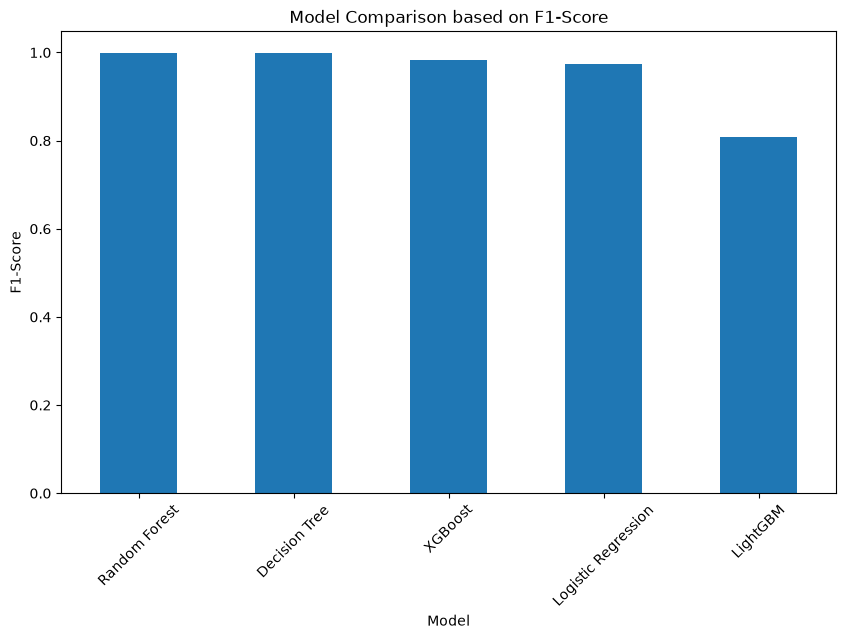

In [28]:
import matplotlib.pyplot as plt

for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    plt.figure(figsize=(10, 6))
    results.plot(
        x="Model",
        y=metric,
        kind="bar",
        figsize=(10, 6),
        legend=False,
    )

    plt.title(f"Model Comparison based on {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.show()